# matmul as linear warping of space

a matrix M sends basis vectors to its columns. the whole space drags along linearly.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 2d: vectors + warped grid, same M

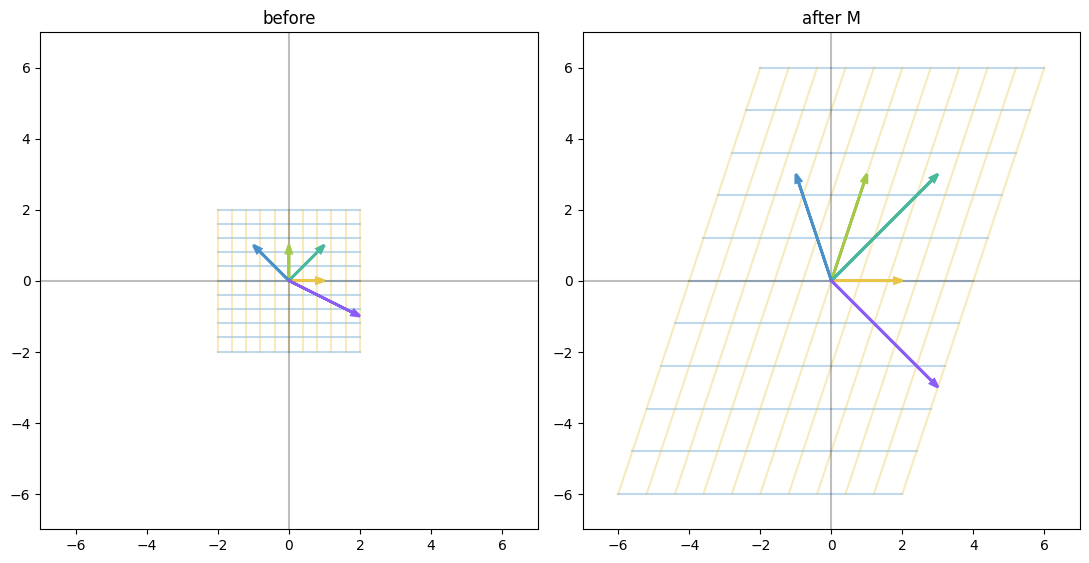

In [9]:
# M: (2, 2) - linear map. column j = where basis vector e_j lands.
M = np.array([[2.0, 1.0],
              [0.0, 3.0]])

# (n_vectors, 2) - some input vectors as rows
vectors = np.array([[1, 0],
                    [0, 1],
                    [1, 1],
                    [-1, 1],
                    [2, -1]], dtype=float)

# (n_vectors, 2) - vectors after M (row-vector convention: v_new = v @ M.T)
transformed = vectors @ M.T

colors_v = ['#E8C547', '#A4C94A', '#4AB89D', '#4A90C9', '#8B5CF6'] # [str] - per-vector colors

n = 11 # gridlines per axis
rng = np.linspace(-2, 2, n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.5))

for y in rng:
    # (n, 2) - line at height y
    line = np.stack([rng, np.full(n, y)], axis=1)
    line_t = line @ M.T
    ax1.plot(line[:, 0], line[:, 1], color='#4A90C9', alpha=0.35)
    ax2.plot(line_t[:, 0], line_t[:, 1], color='#4A90C9', alpha=0.35)

for x in rng:
    line = np.stack([np.full(n, x), rng], axis=1)
    line_t = line @ M.T
    ax1.plot(line[:, 0], line[:, 1], color='#E8C547', alpha=0.35)
    ax2.plot(line_t[:, 0], line_t[:, 1], color='#E8C547', alpha=0.35)

for v, c in zip(vectors, colors_v):
    ax1.arrow(0, 0, v[0], v[1], head_width=0.15, color=c, length_includes_head=True, zorder=5, linewidth=2)
for v, c in zip(transformed, colors_v):
    ax2.arrow(0, 0, v[0], v[1], head_width=0.15, color=c, length_includes_head=True, zorder=5, linewidth=2)

for ax, title in zip([ax1, ax2], ['before', 'after M']):
    ax.set_xlim(-7, 7); ax.set_ylim(-7, 7)
    ax.axhline(0, color='black', alpha=0.25); ax.axvline(0, color='black', alpha=0.25)
    ax.set_aspect('equal')
    ax.set_title(title)
plt.tight_layout(); plt.show()

## 3d: warped lattice, non-axis-aligned M

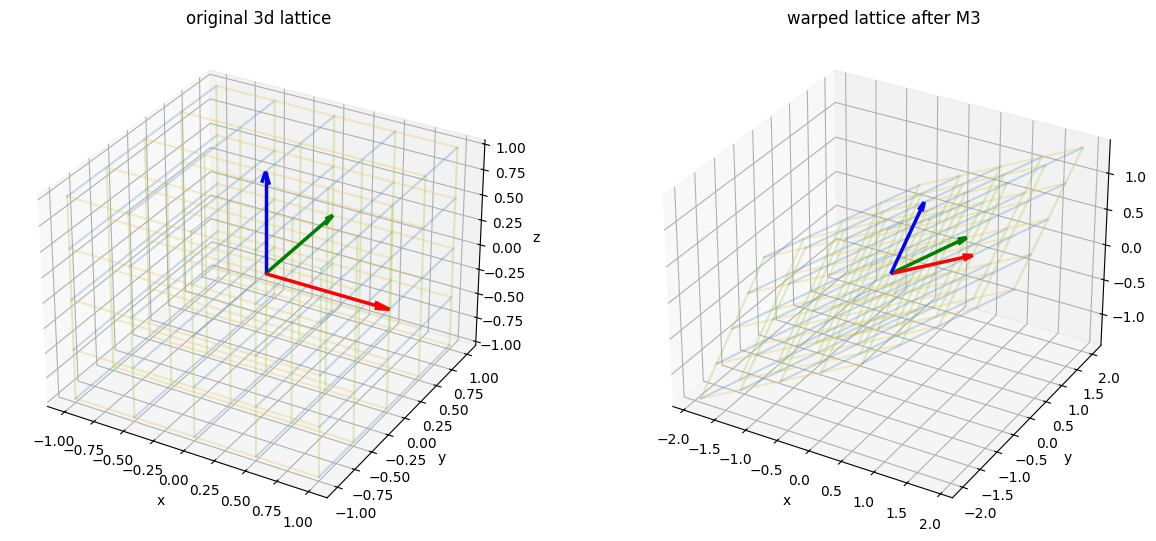

In [10]:
# M3: (3, 3) - each row has multiple non-zero entries so it's clearly not axis-aligned
M3 = np.array([[1.0, 0.6, 0.3],
               [0.5, 1.1, 0.4],
               [0.3, 0.2, 0.9]])

n = 5 # lattice points per axis
rng3 = np.linspace(-1, 1, n)

fig = plt.figure(figsize=(13, 5.5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

for a in rng3:
    for b in rng3:
        # (n, 3) - line along x
        lx = np.stack([rng3, np.full(n, a), np.full(n, b)], axis=1)
        lx_t = lx @ M3.T
        ax1.plot(lx[:, 0], lx[:, 1], lx[:, 2], color='#E8C547', alpha=0.3)
        ax2.plot(lx_t[:, 0], lx_t[:, 1], lx_t[:, 2], color='#E8C547', alpha=0.3)

        # (n, 3) - line along y
        ly = np.stack([np.full(n, a), rng3, np.full(n, b)], axis=1)
        ly_t = ly @ M3.T
        ax1.plot(ly[:, 0], ly[:, 1], ly[:, 2], color='#4A90C9', alpha=0.3)
        ax2.plot(ly_t[:, 0], ly_t[:, 1], ly_t[:, 2], color='#4A90C9', alpha=0.3)

        # (n, 3) - line along z
        lz = np.stack([np.full(n, a), np.full(n, b), rng3], axis=1)
        lz_t = lz @ M3.T
        ax1.plot(lz[:, 0], lz[:, 1], lz[:, 2], color='#A4C94A', alpha=0.3)
        ax2.plot(lz_t[:, 0], lz_t[:, 1], lz_t[:, 2], color='#A4C94A', alpha=0.3)

basis_colors = ['red', 'green', 'blue'] # [str]
for i in range(3):
    e = np.eye(3)[:, i]
    ax1.quiver(0, 0, 0, *e, color=basis_colors[i], arrow_length_ratio=0.12, linewidth=2.5)
    m_col = M3[:, i]
    ax2.quiver(0, 0, 0, *m_col, color=basis_colors[i], arrow_length_ratio=0.12, linewidth=2.5)

for ax, title in zip([ax1, ax2], ['original 3d lattice', 'warped lattice after M3']):
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout(); plt.show()

## high -> low: flatten

3d -> 2d. M_down is (2, 3). the whole 3d space gets squished onto a 2d plane.

key visual: points lined up along the **null direction** of M all collapse to the same 2d point. that's the information loss.

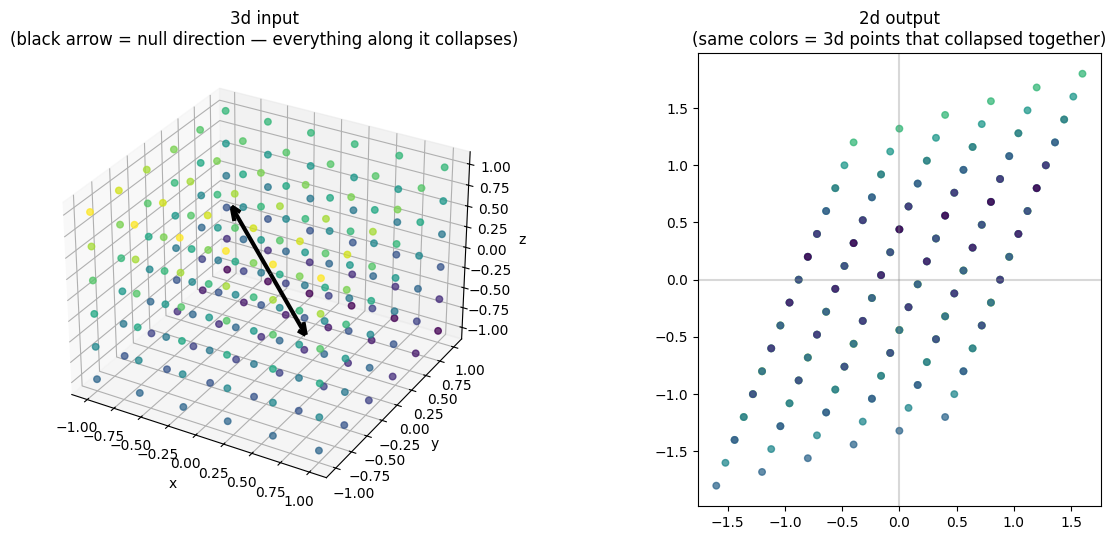

null direction (lives in 3d input space): [ 0.    -0.447  0.894]
M_down @ null_dir (should be ~0): [-0. -0.]


In [11]:
# M_down: (2, 3) - projects 3d -> 2d
M_down = np.array([[1.0, 0.4, 0.2],
                   [0.3, 1.0, 0.5]])

# null direction of M_down: a 3d direction that maps to (0, 0). everything parallel to this collapses together.
# (3,) - right singular vector with smallest singular value
_, _, Vt = np.linalg.svd(M_down)
null_dir = Vt[-1]

n = 6
rng_d = np.linspace(-1, 1, n)

# (n^3, 3) - 3d grid of points
grid_3d = np.array([[x, y, z] for x in rng_d for y in rng_d for z in rng_d])
# (n^3, 2) - 2d images after flattening
grid_2d = grid_3d @ M_down.T

# color each point by its projection onto null direction. points that share this color = points that collapse together.
null_proj = grid_3d @ null_dir # (n^3,) - scalar per point
colors = plt.cm.viridis((null_proj - null_proj.min()) / (null_proj.max() - null_proj.min() + 1e-9))

fig = plt.figure(figsize=(13, 5.5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122)

ax1.scatter(grid_3d[:, 0], grid_3d[:, 1], grid_3d[:, 2], c=colors, s=22, alpha=0.75)

# draw the null direction as a black arrow. every line parallel to this arrow collapses to one 2d point.
ax1.quiver(0, 0, 0, *null_dir*1.3, color='black', linewidth=3, arrow_length_ratio=0.15)
ax1.quiver(0, 0, 0, *(-null_dir*1.3), color='black', linewidth=3, arrow_length_ratio=0.15)

ax1.set_title('3d input\n(black arrow = null direction — everything along it collapses)')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

ax2.scatter(grid_2d[:, 0], grid_2d[:, 1], c=colors, s=22, alpha=0.75)
ax2.axhline(0, color='gray', alpha=0.3); ax2.axvline(0, color='gray', alpha=0.3)
ax2.set_aspect('equal')
ax2.set_title('2d output\n(same colors = 3d points that collapsed together)')

plt.tight_layout(); plt.show()

print('null direction (lives in 3d input space):', null_dir.round(3))
print('M_down @ null_dir (should be ~0):', (M_down @ null_dir).round(6))

## low -> high: lift

2d -> 3d. M_up is (3, 2). the whole 2d plane gets lifted into 3d as a tilted flat slice.

key visual: the output is still 2-dimensional — it's a plane sitting in 3d space. no new info appears; the 2d grid just got tilted and embedded.

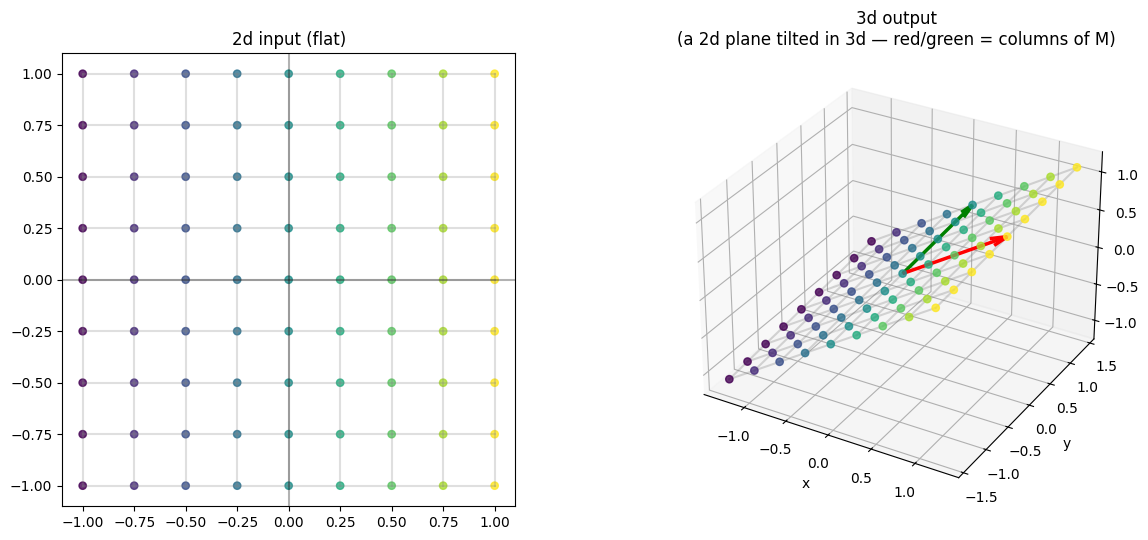

M_up columns (= e_1, e_2 land in 3d as):
  col 0: [1.  0.4 0.6]
  col 1: [0.3 1.  0.5]
image is the plane spanned by these two vectors.


In [12]:
# M_up: (3, 2) - lifts 2d -> 3d. columns = where e_1, e_2 land in 3d.
M_up = np.array([[1.0, 0.3],
                 [0.4, 1.0],
                 [0.6, 0.5]])

n = 9
rng_u = np.linspace(-1, 1, n)

# (n^2, 2) - 2d grid of points
grid_2d_in = np.array([[x, y] for x in rng_u for y in rng_u])
# (n^2, 3) - 3d images (all lying on a tilted 2d plane)
grid_3d_out = grid_2d_in @ M_up.T

# color by 2d x-coord so you can see the grid structure is preserved
colors_u = plt.cm.viridis((grid_2d_in[:, 0] - grid_2d_in[:, 0].min()) / (grid_2d_in[:, 0].max() - grid_2d_in[:, 0].min() + 1e-9))

fig = plt.figure(figsize=(13, 5.5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection='3d')

ax1.scatter(grid_2d_in[:, 0], grid_2d_in[:, 1], c=colors_u, s=28, alpha=0.8)
# draw 2d gridlines for clarity
for v in rng_u:
    ax1.plot(rng_u, np.full(n, v), color='gray', alpha=0.25)
    ax1.plot(np.full(n, v), rng_u, color='gray', alpha=0.25)
ax1.axhline(0, color='black', alpha=0.3); ax1.axvline(0, color='black', alpha=0.3)
ax1.set_aspect('equal')
ax1.set_title('2d input (flat)')

ax2.scatter(grid_3d_out[:, 0], grid_3d_out[:, 1], grid_3d_out[:, 2], c=colors_u, s=28, alpha=0.8)
# draw lifted gridlines in 3d
for v in rng_u:
    line_a = np.stack([rng_u, np.full(n, v)], axis=1) @ M_up.T # (n, 3)
    line_b = np.stack([np.full(n, v), rng_u], axis=1) @ M_up.T # (n, 3)
    ax2.plot(line_a[:, 0], line_a[:, 1], line_a[:, 2], color='gray', alpha=0.3)
    ax2.plot(line_b[:, 0], line_b[:, 1], line_b[:, 2], color='gray', alpha=0.3)

# columns of M_up = where 2d basis vectors land. these span the tilted plane.
for i, c in zip(range(2), ['red', 'green']):
    col = M_up[:, i]
    ax2.quiver(0, 0, 0, *col, color=c, linewidth=2.5, arrow_length_ratio=0.15)

ax2.set_title('3d output\n(a 2d plane tilted in 3d — red/green = columns of M)')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
plt.tight_layout(); plt.show()

print('M_up columns (= e_1, e_2 land in 3d as):')
print('  col 0:', M_up[:, 0].round(3))
print('  col 1:', M_up[:, 1].round(3))
print('image is the plane spanned by these two vectors.')

## summary

- **equal dim** — warp (rotate / stretch / shear). no info lost, no info gained.
- **high -> low** — warp + **flatten** onto a lower-dim slice of the output space. information along the null direction(s) is destroyed.
- **low -> high** — warp + **lift** into a tilted lower-dim slice of the output space. image is still only as large as the input dim; the extra output dims are 'empty' (no info created).

rank of the matrix = true dimensionality of the image. always ≤ min(input_dim, output_dim).